In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
sentiment = pd.read_csv("data/sentiment.csv.csv")
trades= pd.read_csv("data/trades.csv.csv")
print("sentiment shape:", sentiment.shape)
print("Trades shapes:",trades.shape)

sentiment shape: (2644, 4)
Trades shapes: (211224, 16)


In [6]:
import os
print(os.listdir("data"))

['sentiment.csv.csv', 'trades.csv.csv']


In [8]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [10]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [13]:
trades['Timestamp']= pd.to_datetime(trades['Timestamp'])
trades['date'] = trades['Timestamp'].dt.date

In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [16]:
daily_pnl= trades.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Closed PnL
0,1970-01-01,1.029696e+07


In [19]:
trades['Timestamp'].head()

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]

In [20]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], dayfirst=True)
trades['date'] = trades['Timestamp'].dt.date

In [21]:
daily_pnl = trades.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Closed PnL
0,1970-01-01,1.029696e+07


In [22]:
trades = pd.read_csv("data/trades.csv.csv")


In [23]:
trades['Timestamp'].head()

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [24]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

In [25]:
daily_pnl = trades.groupby('date')['Closed PnL'].sum().reset_index()
daily_pnl.head()

,date,Closed PnL
0,2023-03-28,0.000000e+00
1,2023-11-14,1.555034e+02
2,2024-03-09,1.769655e+05
3,2024-07-03,1.587424e+05
4,2024-10-27,3.189461e+06


In [26]:
merged = pd.merge(sentiment, daily_pnl, on='date', how='inner')
merged.head()

,timestamp,value,classification,date,Closed PnL
0,1679981400,59,Greed,2023-03-28,0.000000e+00
1,1699939800,69,Greed,2023-11-14,1.555034e+02
2,1709962200,84,Extreme Greed,2024-03-09,1.769655e+05
3,1719984600,50,Neutral,2024-07-03,1.587424e+05
4,1730007000,74,Greed,2024-10-27,3.189461e+06


In [27]:
correlation = merged['value'].corr(merged['Closed PnL'])
correlation

np.float64(-0.4526619660480213)

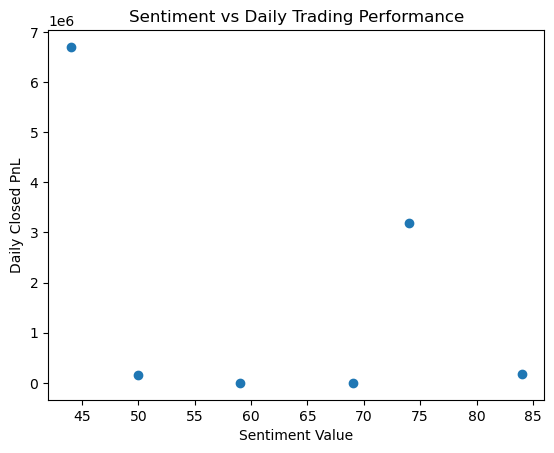

In [28]:
import matplotlib.pyplot as plt

plt.scatter(merged['value'], merged['Closed PnL'])
plt.xlabel("Sentiment Value")
plt.ylabel("Daily Closed PnL")
plt.title("Sentiment vs Daily Trading Performance")
plt.show()

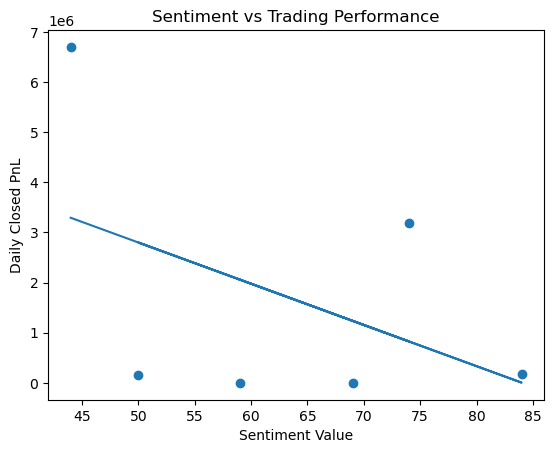

In [29]:
import numpy as np
import matplotlib.pyplot as plt

x = merged['value']
y = merged['Closed PnL']

# Best fit line
m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Sentiment Value")
plt.ylabel("Daily Closed PnL")
plt.title("Sentiment vs Trading Performance")
plt.show()

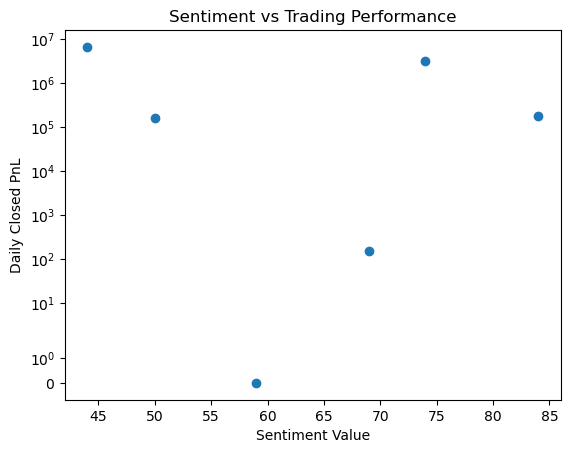

In [30]:
plt.scatter(x, y)
plt.yscale('symlog')  # makes large and small values easier to see
plt.xlabel("Sentiment Value")
plt.ylabel("Daily Closed PnL")
plt.title("Sentiment vs Trading Performance")
plt.show()

In [31]:
sentiment.shape
trades.shape



(211224, 17)

In [32]:
sentiment.isna().sum()
trades.isna().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

In [33]:
sentiment.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [34]:
daily_trader_pnl = trades.groupby(['account','date'])['Closed PnL'].sum().reset_index()
daily_trader_pnl.head()

KeyError: 'account'

In [35]:
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')

In [36]:
daily_trader_pnl = trades.groupby(['account','date'])['Closed PnL'].sum().reset_index()
daily_trader_pnl.head()

KeyError: 'account'

In [38]:
daily_trader_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_trader_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [39]:
daily_trader_pnl.shape

(102, 3)

In [40]:
trades['win'] = trades['Closed PnL'] > 0

win_rate = trades.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [43]:
avg_trade_size = trades.groupby('Account')['Size Tokens'].mean().reset_index()
avg_trade_size.head()

,Account,Size Tokens
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16.167205
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,503.067911
2,0x271b280974205ca63b716753467d5a371de622ab,190.601402
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2073.877613
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,27144.277189


In [ ]:
trades['leverage'].describe()

In [ ]:
trades['leverage'].hist()

In [ ]:
trades_per_day = trades.groupby('date').size().reset_index(name='trade_count')
trades_per_day.head()

In [ ]:
trades['side'].value_counts(normalize=True)

In [45]:
sentiment['date'] = pd.to_datetime(sentiment['timestamp'], unit='s').dt.date

In [46]:
merged_trader = pd.merge(
    daily_trader_pnl,
    sentiment[['date','classification']],
    on='date',
    how='inner'
)

merged_trader.head()

,Account,date,Closed PnL,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,Fear
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,Neutral


In [47]:
merged_trader.groupby('classification')['Closed PnL'].mean()

classification
Extreme Greed     35393.098355
Fear             209372.662205
Greed             99675.516731
Neutral           19842.797260
Name: Closed PnL, dtype: float64

In [49]:
trades_daily_win = trades.groupby(['Account','date'])['win'].mean().reset_index()

merged_win = pd.merge(
    trades_daily_win,
    sentiment[['date','classification']],
    on='date',
    how='inner'
)

merged_win.groupby('classification')['win'].mean()

classification
Extreme Greed    0.336609
Fear             0.415878
Greed            0.374074
Neutral          0.260683
Name: win, dtype: float64

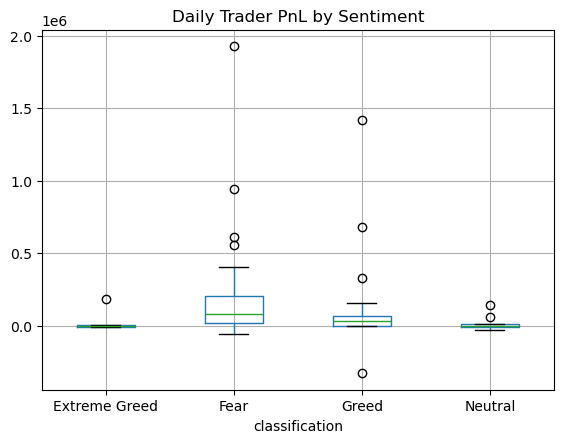

In [50]:
import matplotlib.pyplot as plt

merged_trader.boxplot(column='Closed PnL', by='classification')
plt.title("Daily Trader PnL by Sentiment")
plt.suptitle("")
plt.show()

In [51]:
merged_trades = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='inner'
)

merged_trades.groupby('classification').size()

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

In [55]:
merged_trades.groupby(['classification','Side']).size().unstack()

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


In [57]:
merged_trades.groupby('classification')['Size Tokens'].mean()

classification
Extreme Greed    48736.443323
Fear              3071.523165
Greed             2232.117751
Neutral           1967.302964
Name: Size Tokens, dtype: float64

In [58]:
print("Trader data shape:", trades.shape)
print("Sentiment data shape:", sentiment.shape)

print("\nMissing values:")
print(trades.isnull().sum())
print(sentiment.isnull().sum())

print("\nDuplicates:")
print("Trades:", trades.duplicated().sum())
print("Sentiment:", sentiment.duplicated().sum())

Trader data shape: (211224, 18)
Sentiment data shape: (2644, 4)

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
win                 0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates:
Trades: 0
Sentiment: 0


In [59]:
trades['leverage_group'] = pd.qcut(trades['leverage'], 2, labels=['Low Leverage','High Leverage'])

trades.groupby('leverage_group')['closedPnL'].mean()

KeyError: 'leverage'

In [ ]:
trade_counts = trades.groupby('account').size()

threshold = trade_counts.median()

trades['frequency_group'] = trades['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

trades.groupby('frequency_group')['closedPnL'].mean()